# K-Means Clustering (short explanation):
K-Means clustering is an unsupervised machine learning algorithm used to group data points into K clusters based on similarity.
- You choose the number of clusters (K) in advance.
- The algorithm assigns each data point to the nearest cluster center (centroid).
- It then updates the centroids by calculating the mean of points in each cluster.
- This process repeats until the clusters stabilize.

### Inertia
- Inertia in K-Means clustering refers to a measure of how tightly the data points are clustered around their centroids.

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.5, random_state=0)

kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
labels = kmeans.labels_ 

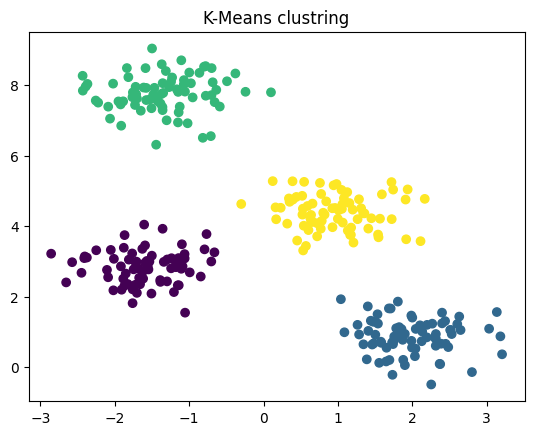

In [3]:
plt.scatter(X[:,0],X[:,1], c=labels)
plt.title('K-Means clustring')
plt.show()

In [4]:
df = sns.load_dataset('diamonds')
x = df[['carat', 'price']]
model = KMeans(n_clusters = 5)
model.fit(x)
Labels = model.labels_
df['Labels'] = Labels
model.inertia_

37597935979.368164

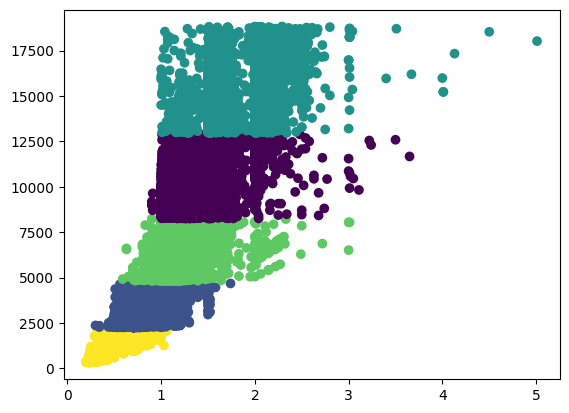

In [5]:
plt.scatter(x.iloc[:, 0],x.iloc[:,1],c=Labels)
plt.show()

## Model Evalution
### Elbow Method
- Run K-Means for a range of values of K (e.g., 1–10).
- For each K, calculate the Within-Cluster Sum of Squares (WCSS) — this measures how close points are to their cluster centroids.
- Plot K (x-axis) vs. WCSS (y-axis).
- Look for the point where the curve starts to bend or flatten — this is the “elbow” point.


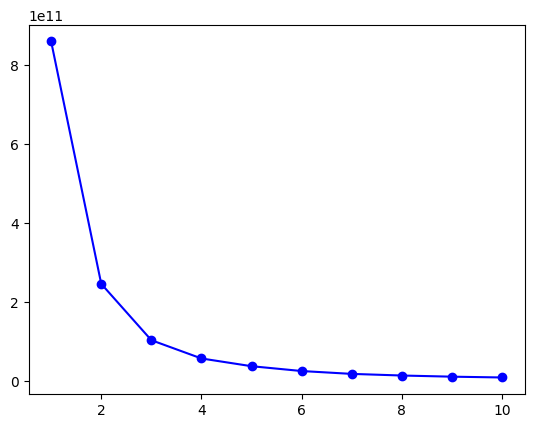

In [6]:
data = sns.load_dataset('diamonds')

feature = ['carat','depth','price']
x = data[feature]

k_values = range(1,11) # test k from 1 to 10
inertias = [] # list to store the inertia values

for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(x)
    inertias.append(kmeans.inertia_)

plt.plot(k_values,inertias, 'bo-')
plt.show()

## Silhouette Method

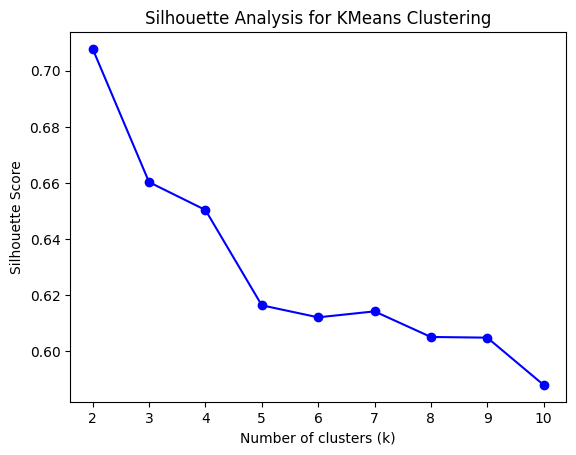

In [7]:
# from sklearn.metrics import silhouette_score
# df = sns.load_dataset('diamonds')
# feature = ['carat','depth','price']
# x = df[feature]

# k_values = range(2, 11)  # silhouette requires at least 2 clusters
# silhouette_scores = []   # store silhouette values

# for k in k_values:
#     kmeans = KMeans(n_clusters=k, random_state=42)
#     kmeans.fit(x)
#     labels = kmeans.labels_
#     score = silhouette_score(x, labels)
#     silhouette_scores.append(score)

# plt.plot(k_values, silhouette_scores, 'bo-')
# plt.xlabel("Number of clusters (k)")
# plt.ylabel("Silhouette Score")
# plt.title("Silhouette Analysis for KMeans Clustering")
# plt.show()

## K-Means++
K-Means++ is an improved version of K-Means clustering that focuses on better initialization of cluster centers (centroids).
- In standard K-Means, centroids are chosen randomly, which can lead to poor clustering results.
- K-Means++ selects initial centroids more strategically:
- The first centroid is chosen randomly.
- Each subsequent centroid is chosen with a probability proportional to its distance from the already chosen centroids.


In [2]:
df = sns.load_dataset('diamonds')
features = ['carat','depth','price']
x = df[features]
k = 3
kmeans = KMeans(n_clusters=3,init='k-means++',random_state=42)
kmeans.fit(x)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'
